# 🧤 Manuel Assist — Simulador de IA para Clasificación de Gestos

**Proyecto:** Manuel Assist — Guante robótico asistivo

**Objetivo:** Simular los datos de los 5 sensores MPU6050 + 1 EMG, generar un dataset sintético de gestos, entrenar un modelo MLP en PyTorch, y probar la clasificación en tiempo real.

**Pipeline:**
1. Definir gestos y mapeo de acciones
2. Simular datos de sensores (31 features por frame)
3. Generar dataset con ventana temporal
4. Entrenar MLP (PyTorch)
5. Evaluar con métricas (accuracy, F1, matriz de confusión)
6. Demo interactiva de clasificación

---

## Celda 0 — Instalación y imports

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
print(f'PyTorch: {torch.__version__}')
print('\n✅ Imports listos')

Dispositivo: cpu
PyTorch: 2.10.0+cpu

✅ Imports listos


## Celda 1 — Definición de gestos y mapeo completo

Cada gesto se define por el estado de los 5 dedos (pulgar, índice, medio, anular, meñique) y la señal EMG.

**Estados de dedo:**
- `resting` = dedo extendido, sin movimiento
- `curled` = dedo enroscado (flexión fuerte)
- `touching_thumb` = punta tocando el pulgar
- `raised` = dedo levantado (extensión activa hacia arriba)
- `hidden` = pulgar oculto debajo de la palma
- `position_N` = posición específica dentro del rango del dedo (para letras/números)

In [ ]:
# ============================================================
# CATÁLOGO COMPLETO DE GESTOS DEL SISTEMA MANUEL ASSIST
# ============================================================
# Cada gesto: nombre, estados de dedos, EMG, acción resultante
#
# Dedos: [pulgar, índice, medio, anular, meñique]
# Estados posibles por dedo:
#   'rest'    = extendido natural
#   'curl'    = enroscado (flexión)
#   'touch'   = tocando otro dedo
#   'raise'   = levantado activamente
#   'hide'    = oculto (solo pulgar)
#   'pos_N'   = posición N dentro del rango (letras/números)

GESTOS = {
    # --- ACCIONES PRINCIPALES ---
    'reposo':        {'dedos': ['rest','rest','rest','rest','rest'],     'emg': 'low',  'accion': 'Nada (idle)'},
    'borrar':        {'dedos': ['rest','curl','rest','rest','rest'],     'emg': 'low',  'accion': 'Backspace / Eliminar'},
    'espacio':       {'dedos': ['touch','touch','rest','rest','rest'],   'emg': 'low',  'accion': 'Barra espaciadora'},
    'enter':         {'dedos': ['rest','touch','touch','rest','rest'],   'emg': 'low',  'accion': 'Enter (índice+medio juntos, subir)'},
    'scroll_down':   {'dedos': ['rest','curl','curl','curl','curl'],    'emg': 'low',  'accion': 'Scroll hacia abajo (4 enroscados)'},
    'scroll_up':     {'dedos': ['rest','curl','curl','curl','rest'],    'emg': 'low',  'accion': 'Scroll hacia arriba (3 enroscados)'},
    'windows':       {'dedos': ['rest','rest','rest','rest','rest'],     'emg': 'high', 'accion': 'Menú Windows (EMG 5s sostenido)'},
    'modo_numerico': {'dedos': ['hide','rest','rest','rest','rest'],     'emg': 'low',  'accion': 'Activa modo numérico (pulgar oculto)'},

    # --- LETRAS POR DEDO (simplificado a zonas) ---
    # Pulgar controla A-G (7 letras, ~7 posiciones)
    'letra_pulgar_1': {'dedos': ['pos_1','rest','rest','rest','rest'],  'emg': 'low',  'accion': 'Letra A-B (pulgar zona 1)'},
    'letra_pulgar_2': {'dedos': ['pos_2','rest','rest','rest','rest'],  'emg': 'low',  'accion': 'Letra C-D (pulgar zona 2)'},
    'letra_pulgar_3': {'dedos': ['pos_3','rest','rest','rest','rest'],  'emg': 'low',  'accion': 'Letra E-G (pulgar zona 3)'},

    # Medio controla H-N (7 letras)
    'letra_medio_1':  {'dedos': ['rest','rest','pos_1','rest','rest'],  'emg': 'low',  'accion': 'Letra H-J (medio zona 1)'},
    'letra_medio_2':  {'dedos': ['rest','rest','pos_2','rest','rest'],  'emg': 'low',  'accion': 'Letra K-L (medio zona 2)'},
    'letra_medio_3':  {'dedos': ['rest','rest','pos_3','rest','rest'],  'emg': 'low',  'accion': 'Letra M-N (medio zona 3)'},

    # Anular controla O-T (6 letras)
    'letra_anular_1': {'dedos': ['rest','rest','rest','pos_1','rest'],  'emg': 'low',  'accion': 'Letra O-P (anular zona 1)'},
    'letra_anular_2': {'dedos': ['rest','rest','rest','pos_2','rest'],  'emg': 'low',  'accion': 'Letra Q-R (anular zona 2)'},
    'letra_anular_3': {'dedos': ['rest','rest','rest','pos_3','rest'],  'emg': 'low',  'accion': 'Letra S-T (anular zona 3)'},

    # Meñique controla U-Z (6 letras)
    'letra_menique_1':{'dedos': ['rest','rest','rest','rest','pos_1'],  'emg': 'low',  'accion': 'Letra U-V (meñique zona 1)'},
    'letra_menique_2':{'dedos': ['rest','rest','rest','rest','pos_2'],  'emg': 'low',  'accion': 'Letra W-X (meñique zona 2)'},
    'letra_menique_3':{'dedos': ['rest','rest','rest','rest','pos_3'],  'emg': 'low',  'accion': 'Letra Y-Z (meñique zona 3)'},
}

# Mapeo de clases
CLASE_NOMBRES = list(GESTOS.keys())
N_CLASES = len(CLASE_NOMBRES)
clase_to_idx = {c: i for i, c in enumerate(CLASE_NOMBRES)}
idx_to_clase = {i: c for c, i in clase_to_idx.items()}

print(f'Total de gestos/clases: {N_CLASES}')
print()
for nombre, info in GESTOS.items():
    print(f'  {nombre:20s} → {info["accion"]}')

Total de gestos/clases: 20

  reposo               → Nada (idle)
  borrar               → Backspace / Eliminar
  espacio              → Barra espaciadora
  enter                → Enter (índice+medio juntos, subir)
  scroll_down          → Scroll hacia abajo (4 enroscados)
  scroll_up            → Scroll hacia arriba (3 enroscados)
  windows              → Menú Windows (EMG 5s sostenido)
  modo_numerico        → Activa modo numérico (pulgar oculto)
  letra_pulgar_1       → Letra A-B (pulgar zona 1)
  letra_pulgar_2       → Letra C-D (pulgar zona 2)
  letra_pulgar_3       → Letra E-G (pulgar zona 3)
  letra_medio_1        → Letra H-J (medio zona 1)
  letra_medio_2        → Letra K-L (medio zona 2)
  letra_medio_3        → Letra M-N (medio zona 3)
  letra_anular_1       → Letra O-P (anular zona 1)
  letra_anular_2       → Letra Q-R (anular zona 2)
  letra_anular_3       → Letra S-T (anular zona 3)
  letra_menique_1      → Letra U-V (meñique zona 1)
  letra_menique_2      → Letra W-X (meñi

## Celda 2 — Simulador de sensores MPU6050 + EMG

Cada MPU6050 produce 6 valores: `ax, ay, az, gx, gy, gz`

- **Acelerómetro (ax,ay,az):** Mide la orientación del dedo por gravedad. Dedo extendido ≈ (0,0,1)g. Dedo enroscado ≈ (0.7,0.3,0.5)g
- **Giroscopio (gx,gy,gz):** Mide velocidad angular. En reposo ≈ 0. Durante movimiento ≈ ±200°/s
- **EMG:** Señal muscular. Reposo ≈ 50-150. Tensión fuerte ≈ 600-900

In [ ]:
# ============================================================
# SIMULADOR DE SENSORES
# ============================================================
# Genera valores realistas de MPU6050 según el estado del dedo

def simular_mpu6050(estado, ruido=0.08):
    """
    Simula los 6 valores de un MPU6050 según el estado del dedo.
    Retorna: [ax, ay, az, gx, gy, gz]

    Los valores están en unidades normalizadas:
    - Acelerómetro: fracción de g (±2g range)
    - Giroscopio: fracción del rango (±2000°/s)
    """
    # Perfiles base por estado (accel_xyz, gyro_xyz)
    perfiles = {
        'rest':   {'accel': [0.0, 0.0, 1.0],   'gyro': [0.0, 0.0, 0.0]},
        'curl':   {'accel': [0.7, 0.3, 0.4],   'gyro': [0.1, 0.3, 0.05]},
        'touch':  {'accel': [0.3, 0.5, 0.6],   'gyro': [0.05, 0.15, 0.02]},
        'raise':  {'accel': [-0.2, 0.1, 0.9],  'gyro': [-0.1, -0.2, 0.0]},
        'hide':   {'accel': [0.8, -0.3, 0.2],  'gyro': [0.2, 0.1, 0.15]},
        'pos_1':  {'accel': [0.15, 0.1, 0.85], 'gyro': [0.02, 0.05, 0.01]},
        'pos_2':  {'accel': [0.35, 0.2, 0.65], 'gyro': [0.04, 0.1, 0.02]},
        'pos_3':  {'accel': [0.55, 0.3, 0.45], 'gyro': [0.06, 0.15, 0.03]},
    }

    perfil = perfiles.get(estado, perfiles['rest'])
    accel = np.array(perfil['accel']) + np.random.normal(0, ruido, 3)
    gyro = np.array(perfil['gyro']) + np.random.normal(0, ruido * 0.5, 3)

    return np.concatenate([accel, gyro])


def simular_emg(nivel, ruido=0.1):
    """
    Simula la señal EMG.
    nivel: 'low' (reposo muscular) o 'high' (tensión sostenida)
    Retorna: valor float normalizado [0, 1]
    """
    if nivel == 'high':
        base = 0.75 + np.random.normal(0, ruido)
    else:
        base = 0.15 + np.random.normal(0, ruido * 0.5)
    return np.clip(base, 0.0, 1.0)


def simular_frame(gesto_nombre):
    """
    Simula un frame completo de datos del guante.
    Retorna: array de 31 valores
        [pulgar_ax..gz, indice_ax..gz, medio_ax..gz, anular_ax..gz, menique_ax..gz, emg]
    """
    gesto = GESTOS[gesto_nombre]
    dedos = gesto['dedos']  # [pulgar, indice, medio, anular, menique]
    emg_nivel = gesto['emg']

    frame = []
    for estado in dedos:
        frame.extend(simular_mpu6050(estado))
    frame.append(simular_emg(emg_nivel))

    return np.array(frame, dtype=np.float32)


# --- Test rápido ---
print('Frame de ejemplo para "reposo":')
frame_test = simular_frame('reposo')
print(f'  Shape: {frame_test.shape}')
print(f'  Valores: {frame_test[:6].round(3)} ... (pulgar) | EMG: {frame_test[-1]:.3f}')
print()
print('Frame de ejemplo para "borrar" (índice enroscado):')
frame_test2 = simular_frame('borrar')
print(f'  Pulgar (rest): {frame_test2[:3].round(3)}')
print(f'  Índice (curl): {frame_test2[6:9].round(3)}')
print(f'  EMG: {frame_test2[-1]:.3f}')
print()
print('Frame de ejemplo para "windows" (EMG alto):')
frame_test3 = simular_frame('windows')
print(f'  EMG: {frame_test3[-1]:.3f} (debería ser alto ~0.7+)')
print()
print(f'✅ Simulador funcionando — {len(frame_test)} features por frame')

Frame de ejemplo para "reposo":
  Shape: (31,)
  Valores: [ 0.04  -0.011  1.052  0.061 -0.009 -0.009] ... (pulgar) | EMG: 0.120

Frame de ejemplo para "borrar" (índice enroscado):
  Pulgar (rest): [ 0.148 -0.001  0.915]
  Índice (curl): [0.543 0.194 0.416]
  EMG: 0.141

Frame de ejemplo para "windows" (EMG alto):
  EMG: 0.680 (debería ser alto ~0.7+)

✅ Simulador funcionando — 31 features por frame


## Celda 3 — Generación del dataset completo

Genera múltiples muestras por gesto. Cada muestra es una **ventana temporal** de W frames consecutivos, lo que permite capturar la dinámica del movimiento (no solo una foto estática).

In [ ]:
# ============================================================
# GENERACIÓN DEL DATASET
# ============================================================

WINDOW_SIZE = 15        # Frames por ventana temporal
FEATURES_PER_FRAME = 31 # 5 MPU6050 × 6 + 1 EMG
SAMPLES_PER_GESTO = 120 # Muestras por gesto

def generar_ventana(gesto_nombre, window_size=WINDOW_SIZE):
    """
    Genera una ventana temporal de frames simulados.
    Añade variación gradual entre frames para simular movimiento real.
    Retorna: array (window_size, 31)
    """
    frames = []
    for i in range(window_size):
        # Añadir variación temporal (el gesto no es idéntico frame a frame)
        ruido_temporal = 0.06 + 0.02 * np.sin(2 * np.pi * i / window_size)
        frame = simular_frame(gesto_nombre)
        # Añadir drift temporal suave
        frame += np.random.normal(0, ruido_temporal, len(frame)) * 0.1
        frames.append(frame)
    return np.array(frames, dtype=np.float32)


def generar_dataset(samples_per_gesto=SAMPLES_PER_GESTO, window_size=WINDOW_SIZE):
    """
    Genera el dataset completo.
    Retorna: X (n_samples, window_size * 31), y (n_samples,)
    """
    X_list = []
    y_list = []

    for gesto_nombre in CLASE_NOMBRES:
        for _ in range(samples_per_gesto):
            ventana = generar_ventana(gesto_nombre, window_size)
            # Aplanar la ventana: (15, 31) → (465,)
            X_list.append(ventana.flatten())
            y_list.append(clase_to_idx[gesto_nombre])

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)

    # Shuffle
    indices = np.random.permutation(len(X))
    return X[indices], y[indices]


# --- Generar ---
print(f'Generando dataset: {N_CLASES} gestos × {SAMPLES_PER_GESTO} muestras = {N_CLASES * SAMPLES_PER_GESTO} total')
print(f'Ventana temporal: {WINDOW_SIZE} frames × {FEATURES_PER_FRAME} features = {WINDOW_SIZE * FEATURES_PER_FRAME} features por muestra')
print()

X_data, y_data = generar_dataset()

print(f'X shape: {X_data.shape}')
print(f'y shape: {y_data.shape}')
print(f'Clases únicas: {np.unique(y_data).shape[0]}')
print()

# Distribución de clases
unique, counts = np.unique(y_data, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Clase {u:2d} ({idx_to_clase[u]:20s}): {c} muestras')

print(f'\n✅ Dataset generado: {X_data.shape[0]} muestras, {X_data.shape[1]} features')

Generando dataset: 20 gestos × 120 muestras = 2400 total
Ventana temporal: 15 frames × 31 features = 465 features por muestra

X shape: (2400, 465)
y shape: (2400,)
Clases únicas: 20

  Clase  0 (reposo              ): 120 muestras
  Clase  1 (borrar              ): 120 muestras
  Clase  2 (espacio             ): 120 muestras
  Clase  3 (enter               ): 120 muestras
  Clase  4 (scroll_down         ): 120 muestras
  Clase  5 (scroll_up           ): 120 muestras
  Clase  6 (windows             ): 120 muestras
  Clase  7 (modo_numerico       ): 120 muestras
  Clase  8 (letra_pulgar_1      ): 120 muestras
  Clase  9 (letra_pulgar_2      ): 120 muestras
  Clase 10 (letra_pulgar_3      ): 120 muestras
  Clase 11 (letra_medio_1       ): 120 muestras
  Clase 12 (letra_medio_2       ): 120 muestras
  Clase 13 (letra_medio_3       ): 120 muestras
  Clase 14 (letra_anular_1      ): 120 muestras
  Clase 15 (letra_anular_2      ): 120 muestras
  Clase 16 (letra_anular_3      ): 120 muestras


## Celda 4 — Normalización y split train/val/test

In [ ]:
# ============================================================
# NORMALIZACIÓN Y SPLIT
# ============================================================

# Normalizar con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# Split: 70% train, 15% val, 15% test
n_total = len(X_scaled)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)
n_test = n_total - n_train - n_val

X_train, y_train = X_scaled[:n_train], y_data[:n_train]
X_val, y_val = X_scaled[n_train:n_train+n_val], y_data[n_train:n_train+n_val]
X_test, y_test = X_scaled[n_train+n_val:], y_data[n_train+n_val:]

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# PyTorch Dataset
class GestureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = GestureDataset(X_train, y_train)
val_ds = GestureDataset(X_val, y_val)
test_ds = GestureDataset(X_test, y_test)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'\n✅ Dataloaders listos (batch_size={BATCH_SIZE})')

Train: 1680 | Val: 360 | Test: 360

✅ Dataloaders listos (batch_size=32)


## Celda 5 — Arquitectura del MLP

Red neuronal fully-connected con Batch Normalization y Dropout.

```
Input(465) → FC(256) → BN → ReLU → Dropout(0.3)
           → FC(128) → BN → ReLU → Dropout(0.3)
           → FC(64)  → BN → ReLU → Dropout(0.2)
           → FC(20)  → Softmax
```

In [ ]:
# ============================================================
# MODELO MLP
# ============================================================

class GestureClassifierMLP(nn.Module):
    """
    MLP para clasificación de gestos del guante Manuel Assist.

    Input:  vector aplanado de ventana temporal (WINDOW_SIZE × 31)
    Output: probabilidades sobre N_CLASES gestos
    """
    def __init__(self, input_size, n_classes, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            # Capa 1
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Capa 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Capa 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.67),

            # Salida
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.network(x)


INPUT_SIZE = WINDOW_SIZE * FEATURES_PER_FRAME  # 15 × 31 = 465
model = GestureClassifierMLP(INPUT_SIZE, N_CLASES).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nParámetros totales:      {total_params:,}')
print(f'Parámetros entrenables:  {trainable_params:,}')
print(f'Tamaño estimado (MB):    {total_params * 4 / 1024 / 1024:.2f}')
print(f'\n✅ Modelo creado en {device}')

GestureClassifierMLP(
  (network): Sequential(
    (0): Linear(in_features=465, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.201, inplace=False)
    (12): Linear(in_features=64, out_features=20, bias=True)
  )
)

Parámetros totales:      162,644
Parámetros entrenables:  162,644
Tamaño estimado (MB):    0.62

✅ Modelo creado en cpu


## Celda 6 — Entrenamiento

In [ ]:
# ============================================================
# ENTRENAMIENTO
# ============================================================

EPOCHS = 60
LR = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

# Historial
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_epoch = 0

print(f'Entrenando {EPOCHS} epochs | LR={LR} | CosineAnnealing')
print(f'{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'Train Acc':>10} | {'Val Acc':>10} | {'LR':>10}')
print('-' * 75)

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
        train_correct += (outputs.argmax(1) == y_batch).sum().item()
        train_total += X_batch.size(0)

    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)
            val_correct += (outputs.argmax(1) == y_batch).sum().item()
            val_total += X_batch.size(0)

    # Métricas
    t_loss = train_loss / train_total
    v_loss = val_loss / val_total
    t_acc = train_correct / train_total
    v_acc = val_correct / val_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    # Guardar mejor modelo
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'manuel_assist_best.pth')

    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr_now = scheduler.get_last_lr()[0]
        print(f'{epoch+1:>6} | {t_loss:>10.4f} | {v_loss:>10.4f} | {t_acc:>9.1%} | {v_acc:>9.1%} | {lr_now:>10.6f}')

print(f'\n✅ Entrenamiento completo. Mejor val_acc: {best_val_acc:.1%} en epoch {best_epoch}')

Entrenando 60 epochs | LR=0.001 | CosineAnnealing
 Epoch | Train Loss |   Val Loss |  Train Acc |    Val Acc |         LR
---------------------------------------------------------------------------
     1 |     2.0832 |     1.3016 |     48.5% |     75.3% |   0.000999
     5 |     0.4311 |     0.1912 |     92.4% |    100.0% |   0.000983
    10 |     0.1957 |     0.0487 |     95.4% |     99.7% |   0.000934
    15 |     0.1212 |     0.0355 |     96.7% |     99.4% |   0.000855
    20 |     0.0729 |     0.0189 |     98.4% |     99.7% |   0.000753
    25 |     0.0624 |     0.0109 |     98.6% |    100.0% |   0.000633
    30 |     0.0543 |     0.0094 |     98.6% |    100.0% |   0.000505
    35 |     0.0313 |     0.0092 |     99.5% |    100.0% |   0.000377
    40 |     0.0327 |     0.0106 |     99.3% |     99.7% |   0.000258
    45 |     0.0291 |     0.0080 |     99.4% |     99.7% |   0.000155
    50 |     0.0265 |     0.0078 |     99.5% |     99.7% |   0.000076
    55 |     0.0243 |     0.0084

## Celda 7 — Curvas de entrenamiento

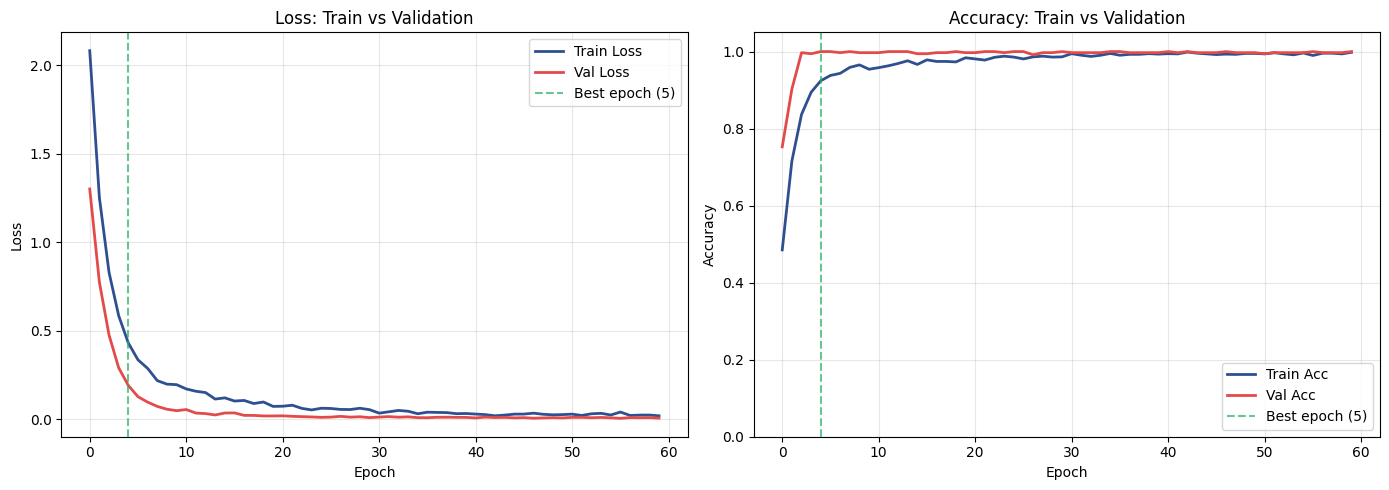

📊 Gráficas guardadas en training_curves.png


In [ ]:
# ============================================================
# GRÁFICAS DE ENTRENAMIENTO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='#2E5090', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', color='#E24B4A', linewidth=2)
axes[0].axvline(best_epoch-1, color='#27AE60', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss: Train vs Validation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', color='#2E5090', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', color='#E24B4A', linewidth=2)
axes[1].axvline(best_epoch-1, color='#27AE60', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy: Train vs Validation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Gráficas guardadas en training_curves.png')

## Celda 8 — Evaluación en Test Set + Matriz de Confusión

REPORTE DE CLASIFICACIÓN — TEST SET
                 precision    recall  f1-score   support

         reposo      1.000     1.000     1.000        15
         borrar      1.000     1.000     1.000        16
        espacio      1.000     1.000     1.000        21
          enter      1.000     1.000     1.000        21
    scroll_down      1.000     1.000     1.000        20
      scroll_up      1.000     1.000     1.000        24
        windows      1.000     1.000     1.000        17
  modo_numerico      1.000     1.000     1.000        18
 letra_pulgar_1      1.000     1.000     1.000        21
 letra_pulgar_2      1.000     1.000     1.000        16
 letra_pulgar_3      1.000     1.000     1.000        22
  letra_medio_1      1.000     1.000     1.000        14
  letra_medio_2      1.000     1.000     1.000        14
  letra_medio_3      1.000     1.000     1.000        17
 letra_anular_1      1.000     1.000     1.000        18
 letra_anular_2      1.000     1.000     1.000     

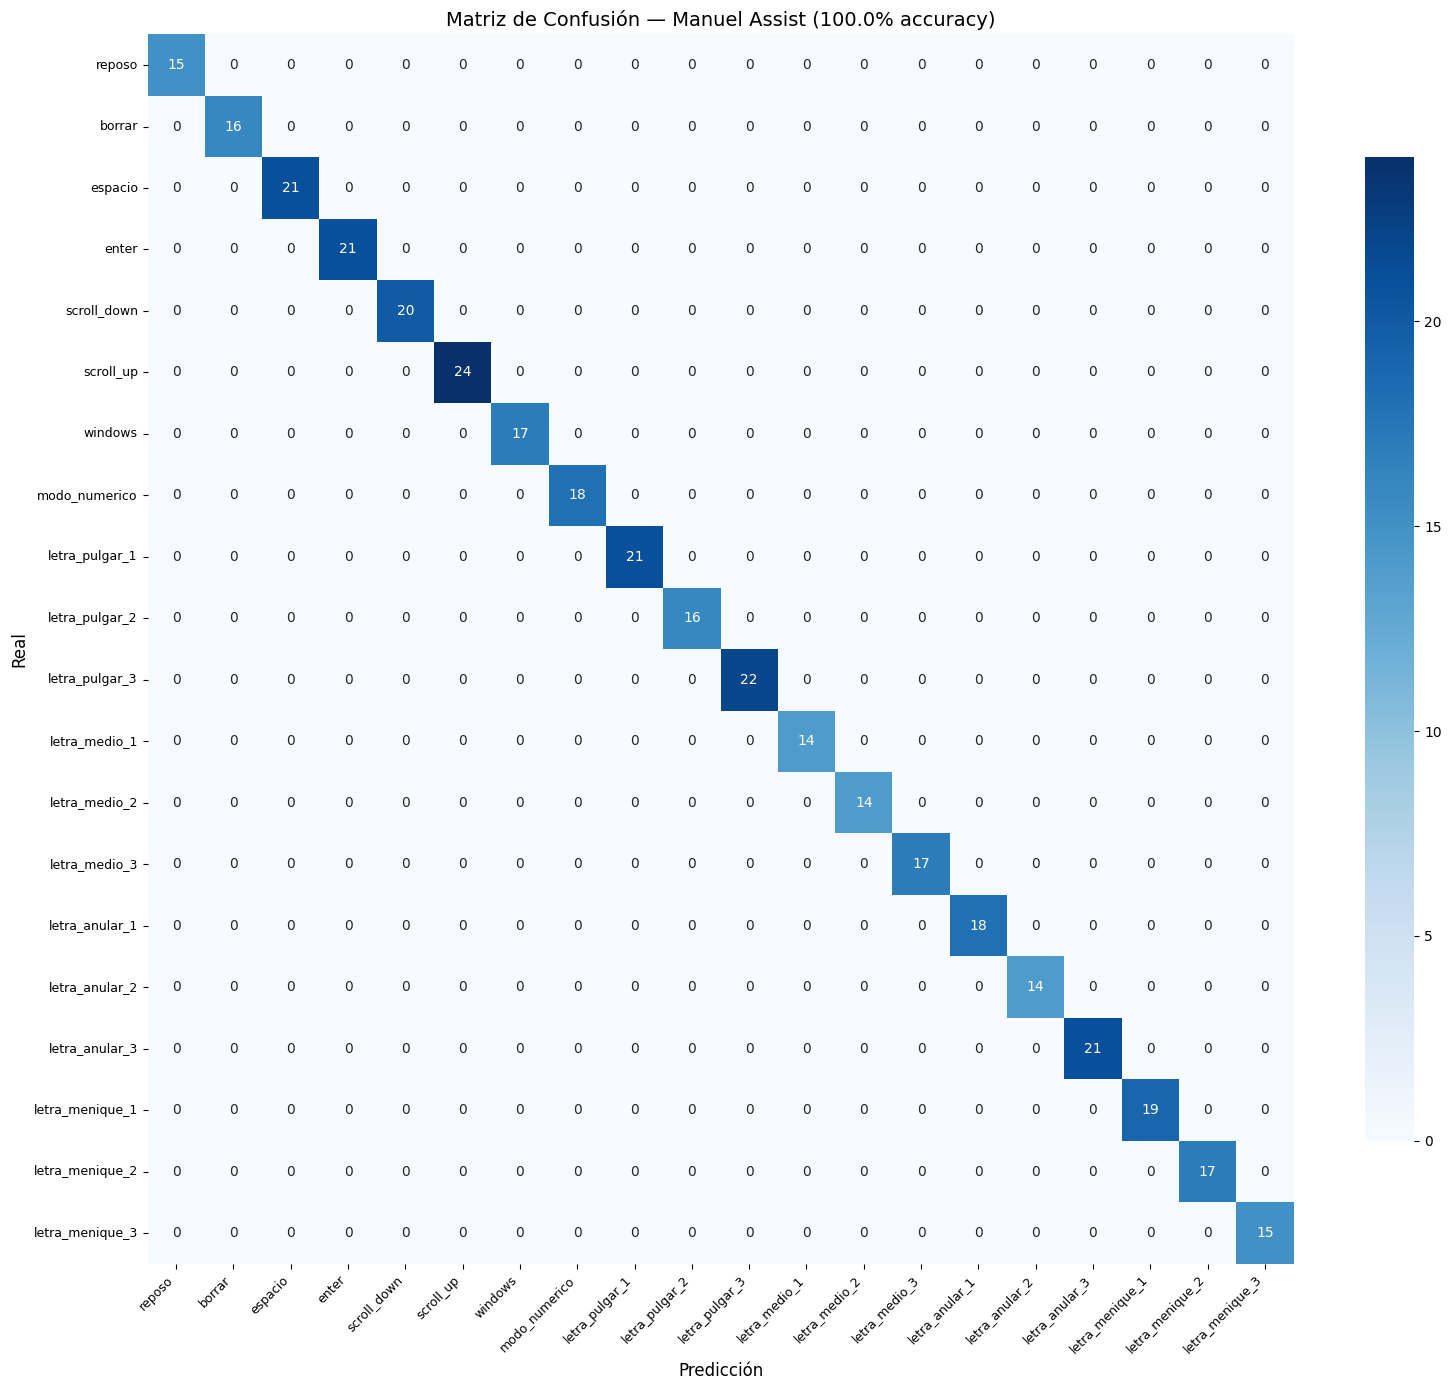

📊 Matriz guardada en confusion_matrix.png


In [ ]:
# ============================================================
# EVALUACIÓN FINAL EN TEST SET
# ============================================================

# Cargar mejor modelo
model.load_state_dict(torch.load('manuel_assist_best.pth', weights_only=True))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification Report
print('=' * 80)
print('REPORTE DE CLASIFICACIÓN — TEST SET')
print('=' * 80)
target_names = [idx_to_clase[i] for i in range(N_CLASES)]
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))

# Métricas globales
test_acc = (all_preds == all_labels).mean()
test_f1 = f1_score(all_labels, all_preds, average='weighted')
print(f'\nTest Accuracy: {test_acc:.1%}')
print(f'Test F1 (weighted): {test_f1:.4f}')

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión — Manuel Assist ({test_acc:.1%} accuracy)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Matriz guardada en confusion_matrix.png')

## Celda 9 — Demo interactiva: simular gesto y clasificar

Simula gestos en tiempo real y muestra la predicción del modelo con probabilidades.

In [ ]:
# ============================================================
# DEMO INTERACTIVA DE CLASIFICACIÓN
# ============================================================

def predecir_gesto(gesto_simulado):
    """
    Simula un gesto, lo procesa y clasifica con el modelo.
    Muestra el resultado con probabilidades top-5.
    """
    # 1. Generar ventana de datos simulados
    ventana = generar_ventana(gesto_simulado)
    x_flat = ventana.flatten().reshape(1, -1)

    # 2. Normalizar (con el scaler ya ajustado)
    x_scaled = scaler.transform(x_flat)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32).to(device)

    # 3. Inferencia
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    # 4. Resultados
    pred_idx = probs.argmax()
    pred_nombre = idx_to_clase[pred_idx]
    pred_accion = GESTOS[pred_nombre]['accion']

    # Top 5 predicciones
    top5_idx = probs.argsort()[::-1][:5]

    return pred_nombre, pred_accion, probs, top5_idx


def demo_gesto(gesto_simulado):
    """Muestra la predicción con formato visual."""
    pred_nombre, pred_accion, probs, top5 = predecir_gesto(gesto_simulado)
    correcto = pred_nombre == gesto_simulado
    emoji = '✅' if correcto else '❌'

    print(f'\n{'='*60}')
    print(f'  Gesto simulado:  {gesto_simulado}')
    print(f'  Predicción:      {pred_nombre} {emoji}')
    print(f'  Acción:          {pred_accion}')
    print(f'  Confianza:       {probs[top5[0]]:.1%}')
    print(f'{'='*60}')
    print(f'  Top 5 probabilidades:')
    for rank, idx in enumerate(top5):
        bar_len = int(probs[idx] * 30)
        bar = '█' * bar_len + '░' * (30 - bar_len)
        nombre = idx_to_clase[idx]
        print(f'    {rank+1}. {nombre:20s} {bar} {probs[idx]:.1%}')
    return correcto


# --- Ejecutar demo con todos los gestos ---
print('🧤 DEMO DE CLASIFICACIÓN EN TIEMPO REAL')
print('Simulando cada gesto y clasificando con el modelo entrenado...\n')

correctos = 0
total = 0

for gesto in CLASE_NOMBRES:
    ok = demo_gesto(gesto)
    correctos += int(ok)
    total += 1

print(f'\n\n{'='*60}')
print(f'  RESULTADO DEMO: {correctos}/{total} correctos ({correctos/total:.0%})')
print(f'{'='*60}')

🧤 DEMO DE CLASIFICACIÓN EN TIEMPO REAL
Simulando cada gesto y clasificando con el modelo entrenado...


  Gesto simulado:  reposo
  Predicción:      reposo ✅
  Acción:          Nada (idle)
  Confianza:       71.7%
  Top 5 probabilidades:
    1. reposo               █████████████████████░░░░░░░░░ 71.7%
    2. letra_anular_1       ███░░░░░░░░░░░░░░░░░░░░░░░░░░░ 10.0%
    3. letra_pulgar_1       ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 6.8%
    4. letra_menique_1      █░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 6.6%
    5. letra_medio_1        ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 2.9%

  Gesto simulado:  borrar
  Predicción:      borrar ✅
  Acción:          Backspace / Eliminar
  Confianza:       96.1%
  Top 5 probabilidades:
    1. borrar               ████████████████████████████░░ 96.1%
    2. reposo               ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.9%
    3. scroll_up            ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.7%
    4. espacio              ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ 0.4%
    5. letra_anular_1       ░░░░░░░░░░░

## Celda 10 — Demo interactiva con widgets

Selecciona un gesto con un dropdown y el modelo lo clasifica al instante.

In [ ]:
# ============================================================
# DEMO CON WIDGETS INTERACTIVOS
# ============================================================

dropdown = widgets.Dropdown(
    options=[(f'{g} → {GESTOS[g]["accion"]}', g) for g in CLASE_NOMBRES],
    value='reposo',
    description='Gesto:',
    style={'description_width': '80px'},
    layout=widgets.Layout(width='500px')
)

btn = widgets.Button(
    description='🎯 Clasificar',
    button_style='success',
    layout=widgets.Layout(width='150px', height='35px')
)

btn_random = widgets.Button(
    description='🎲 Aleatorio',
    button_style='info',
    layout=widgets.Layout(width='150px', height='35px')
)

btn_stress = widgets.Button(
    description='⚡ Stress Test (x100)',
    button_style='warning',
    layout=widgets.Layout(width='180px', height='35px')
)

output = widgets.Output()

def on_classify(b):
    with output:
        clear_output()
        demo_gesto(dropdown.value)

def on_random(b):
    with output:
        clear_output()
        gesto = np.random.choice(CLASE_NOMBRES)
        dropdown.value = gesto
        demo_gesto(gesto)

def on_stress(b):
    with output:
        clear_output()
        print('⚡ STRESS TEST — 100 predicciones aleatorias\n')
        ok = 0
        for i in range(100):
            gesto = np.random.choice(CLASE_NOMBRES)
            pred, _, probs, _ = predecir_gesto(gesto)
            if pred == gesto:
                ok += 1
        print(f'Resultado: {ok}/100 correctos ({ok}%)')
        print(f'\n{"✅ EXCELENTE" if ok >= 90 else "⚠️ Revisar gestos confusos" if ok >= 70 else "❌ Modelo necesita ajuste"}')

btn.on_click(on_classify)
btn_random.on_click(on_random)
btn_stress.on_click(on_stress)

display(widgets.HTML('<h3>🧤 Manuel Assist — Demo de Clasificación de Gestos</h3>'))
display(dropdown)
display(widgets.HBox([btn, btn_random, btn_stress]))
display(output)

HTML(value='<h3>🧤 Manuel Assist — Demo de Clasificación de Gestos</h3>')

Dropdown(description='Gesto:', layout=Layout(width='500px'), options=(('reposo → Nada (idle)', 'reposo'), ('bo…

Output()

## Celda 11 — Exportar modelo para producción

Guarda el modelo, el scaler y los metadatos para usarlos en el script Python receptor del ESP32.

In [ ]:
# ============================================================
# EXPORTAR MODELO Y ARTEFACTOS
# ============================================================
import json
import pickle

# 1. Modelo PyTorch
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': INPUT_SIZE,
    'n_classes': N_CLASES,
    'window_size': WINDOW_SIZE,
    'features_per_frame': FEATURES_PER_FRAME,
    'clase_nombres': CLASE_NOMBRES,
    'best_val_acc': best_val_acc,
    'best_epoch': best_epoch,
}, 'manuel_assist_model.pth')
print('✅ Modelo guardado: manuel_assist_model.pth')

# 2. Scaler
with open('manuel_assist_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Scaler guardado: manuel_assist_scaler.pkl')

# 3. Metadatos (para el script receptor Python)
metadata = {
    'gestos': {nombre: info['accion'] for nombre, info in GESTOS.items()},
    'n_clases': N_CLASES,
    'window_size': WINDOW_SIZE,
    'features_per_frame': FEATURES_PER_FRAME,
    'input_size': INPUT_SIZE,
    'test_accuracy': float(test_acc),
    'test_f1_weighted': float(test_f1),
}
with open('manuel_assist_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print('✅ Metadatos guardados: manuel_assist_metadata.json')

# 4. Dataset CSV (para referencia)
df_cols = []
dedos_nombres = ['pulgar', 'indice', 'medio', 'anular', 'menique']
sensor_nombres = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
for frame_i in range(WINDOW_SIZE):
    for dedo in dedos_nombres:
        for sensor in sensor_nombres:
            df_cols.append(f'f{frame_i}_{dedo}_{sensor}')
    df_cols.append(f'f{frame_i}_emg')

df = pd.DataFrame(X_data, columns=df_cols)
df['label'] = [idx_to_clase[y] for y in y_data]
df['label_idx'] = y_data
df.to_csv('manuel_assist_dataset.csv', index=False)
print(f'✅ Dataset guardado: manuel_assist_dataset.csv ({len(df)} filas, {len(df.columns)} columnas)')

print(f'\n📦 Archivos exportados:')
print(f'  • manuel_assist_model.pth      — Modelo PyTorch')
print(f'  • manuel_assist_scaler.pkl      — Normalizador')
print(f'  • manuel_assist_metadata.json   — Configuración')
print(f'  • manuel_assist_dataset.csv     — Dataset completo')
print(f'  • training_curves.png           — Gráficas de entrenamiento')
print(f'  • confusion_matrix.png          — Matriz de confusión')

✅ Modelo guardado: manuel_assist_model.pth
✅ Scaler guardado: manuel_assist_scaler.pkl
✅ Metadatos guardados: manuel_assist_metadata.json
✅ Dataset guardado: manuel_assist_dataset.csv (2400 filas, 467 columnas)

📦 Archivos exportados:
  • manuel_assist_model.pth      — Modelo PyTorch
  • manuel_assist_scaler.pkl      — Normalizador
  • manuel_assist_metadata.json   — Configuración
  • manuel_assist_dataset.csv     — Dataset completo
  • training_curves.png           — Gráficas de entrenamiento
  • confusion_matrix.png          — Matriz de confusión


## Celda 12 — Script receptor (referencia)

Este es el código que correrá en la PC para recibir datos del ESP32 y ejecutar acciones. **No se ejecuta en Colab** — es referencia para cuando el hardware esté listo.

In [ ]:
# ============================================================
# REFERENCIA: Script receptor para PC (NO ejecutar en Colab)
# ============================================================
# Este script recibirá datos reales del ESP32 via UDP
# y ejecutará acciones con pyautogui/pynput

SCRIPT_RECEPTOR = '''
#!/usr/bin/env python3
"""
Manuel Assist — Script Receptor
Recibe datos del ESP32 vía Wi-Fi UDP y ejecuta acciones de mouse/teclado.

Requisitos:
  pip install torch pyautogui pynput numpy

Uso:
  python receptor_manuel_assist.py
"""
import socket
import struct
import numpy as np
import torch
import torch.nn as nn
import pickle
import json
import pyautogui
from collections import deque
import time

# --- Configuración ---
UDP_IP = "0.0.0.0"
UDP_PORT = 4210
WINDOW_SIZE = 15
FEATURES_PER_FRAME = 31
CONFIDENCE_THRESHOLD = 0.65  # Mínimo de confianza para ejecutar acción
EMG_THRESHOLD = 0.6          # Umbral para detección EMG sostenido
EMG_DURATION = 5.0           # Segundos de EMG sostenido para Windows


# --- Cargar modelo ---
class GestureClassifierMLP(nn.Module):
    def __init__(self, input_size, n_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.network(x)


# Cargar artefactos
checkpoint = torch.load("manuel_assist_model.pth", weights_only=False)
with open("manuel_assist_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open("manuel_assist_metadata.json") as f:
    metadata = json.load(f)

model = GestureClassifierMLP(checkpoint["input_size"], checkpoint["n_classes"])
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

clase_nombres = checkpoint["clase_nombres"]
gestos_acciones = metadata["gestos"]


# --- Mapeo de acciones ---
def ejecutar_accion(gesto, confianza):
    """Ejecuta la acción correspondiente al gesto detectado."""
    if confianza < CONFIDENCE_THRESHOLD:
        return  # No hacer nada si la confianza es baja

    acciones = {
        "borrar":      lambda: pyautogui.press("backspace"),
        "espacio":     lambda: pyautogui.press("space"),
        "enter":       lambda: pyautogui.press("enter"),
        "scroll_down": lambda: pyautogui.scroll(-3),
        "scroll_up":   lambda: pyautogui.scroll(3),
        "windows":     lambda: pyautogui.press("win"),
        # Letras (mapeo simplificado por zona)
        "letra_pulgar_1": lambda: pyautogui.press("a"),
        "letra_pulgar_2": lambda: pyautogui.press("c"),
        "letra_pulgar_3": lambda: pyautogui.press("e"),
        "letra_medio_1":  lambda: pyautogui.press("h"),
        "letra_medio_2":  lambda: pyautogui.press("k"),
        "letra_medio_3":  lambda: pyautogui.press("m"),
        "letra_anular_1": lambda: pyautogui.press("o"),
        "letra_anular_2": lambda: pyautogui.press("q"),
        "letra_anular_3": lambda: pyautogui.press("s"),
        "letra_menique_1":lambda: pyautogui.press("u"),
        "letra_menique_2":lambda: pyautogui.press("w"),
        "letra_menique_3":lambda: pyautogui.press("y"),
    }

    if gesto in acciones:
        acciones[gesto]()
        print(f"  → Ejecutado: {gesto} ({confianza:.0%})")


# --- Loop principal ---
def main():
    sock = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
    sock.bind((UDP_IP, UDP_PORT))
    print(f"Escuchando en {UDP_IP}:{UDP_PORT}...")

    buffer = deque(maxlen=WINDOW_SIZE)  # Buffer circular de frames
    emg_timer = 0.0  # Timer para detección EMG sostenida

    while True:
        data, addr = sock.recvfrom(256)  # Recibir paquete UDP

        # Parsear 31 floats del paquete
        if len(data) >= FEATURES_PER_FRAME * 4:
            frame = struct.unpack(f"{FEATURES_PER_FRAME}f", data[:FEATURES_PER_FRAME*4])
            buffer.append(np.array(frame, dtype=np.float32))

            # EMG sostenido (detección directa, sin IA)
            emg_val = frame[-1]  # Último valor = EMG
            if emg_val > EMG_THRESHOLD:
                emg_timer += 0.033  # ~30 fps
                if emg_timer >= EMG_DURATION:
                    pyautogui.press("win")
                    emg_timer = 0
            else:
                emg_timer = 0

            # Clasificar cuando el buffer está lleno
            if len(buffer) == WINDOW_SIZE:
                ventana = np.array(list(buffer)).flatten().reshape(1, -1)
                x_scaled = scaler.transform(ventana)
                x_tensor = torch.tensor(x_scaled, dtype=torch.float32)

                with torch.no_grad():
                    logits = model(x_tensor)
                    probs = torch.softmax(logits, dim=1).numpy()[0]

                pred_idx = probs.argmax()
                pred_nombre = clase_nombres[pred_idx]
                pred_conf = probs[pred_idx]

                if pred_nombre != "reposo":
                    ejecutar_accion(pred_nombre, pred_conf)


if __name__ == "__main__":
    main()
'''

# Guardar como archivo
with open('receptor_manuel_assist.py', 'w') as f:
    f.write(SCRIPT_RECEPTOR)

print('✅ Script receptor guardado: receptor_manuel_assist.py')
print('\nEste script se ejecutará en la PC cuando el hardware esté listo.')
print('Uso: python receptor_manuel_assist.py')
print('\nRequisitos: pip install torch pyautogui pynput numpy')

✅ Script receptor guardado: receptor_manuel_assist.py

Este script se ejecutará en la PC cuando el hardware esté listo.
Uso: python receptor_manuel_assist.py

Requisitos: pip install torch pyautogui pynput numpy


---
## Resumen

| Componente | Detalle |
|---|---|
| **Entrada** | 5× MPU6050 (30 vals) + 1× EMG (1 val) = 31 features/frame |
| **Ventana temporal** | 15 frames → 465 features por muestra |
| **Modelo** | MLP: 465 → 256 → 128 → 64 → 20 clases |
| **Dataset** | 20 gestos × 120 muestras = 2400 total (sintético) |
| **Entrenamiento** | 60 epochs, Adam + CosineAnnealing |
| **Ejecución** | PC (Python) — recibe datos vía Wi-Fi UDP del ESP32 |
| **EMG Windows** | Umbral determinístico (5s sostenido), sin IA |

### Siguiente paso
Cuando el hardware esté armado, reemplazar los datos simulados por datos reales grabados con el guante. El pipeline de entrenamiento es el mismo — solo cambia la fuente de datos.